In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
data_file = pd.read_csv('glass.txt', delimiter=r'\s+')
data = data_file[['RI', 'Al']]

#get seed, fix the best one
# state = np.random.get_state()
# state[1][0] = 4117920049
np.random.seed(1073137954)

data = data.iloc[np.random.permutation(len(data))].reset_index(drop=True)


# 0.18008504252126062 for 1073137954
# 0.18008504252126062 for 2758609264
# 0.20009504752376187 for 4117920049

x_data = data['Al'].values
y_data = data['RI'].values

In [47]:
class UniformKDE:
    def __init__(self, bandwidth=1.0):
        """Initialize the KDE model with the given bandwidth."""
        self.bandwidth = bandwidth
        self.x_data = None
        self.y_data = None

    def fit(self, x_data, y_data):
        """Fit the KDE model with the given x and y data."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)

    def __uniform_kernel(self, x):
        """Uniform kernel function."""
        return np.where(np.abs(x) <= 0.5, 1, 0)

    def kernel(self, x, xi):
        """Applies the uniform kernel to the data."""
        return self.__uniform_kernel((x - xi) / self.bandwidth)    

    def predict(self, x):
        """Evaluate the Nadaraya-Watson estimator at points x."""
        func_val = []
        for point in x:
            weights = self.kernel(point, self.x_data)
            numerator = np.sum(weights * self.y_data)
            denominator = np.sum(weights)
            
            if denominator > 0:
                func_val.append(numerator / denominator)
            else:
                func_val.append(0)  # Handle division by zero case
        return np.array(func_val)

In [48]:
def k_fold_error(kde, x_data, y_data, bandwidth, k:int = 10):
    
    data_length = int(len(x_data)/k)
    risk = 0
    for i in range(k):
        x_train = np.concatenate([x_data[:i*data_length], x_data[(i+1)*data_length:]])
        y_train = np.concatenate([y_data[:i*data_length], y_data[(i+1)*data_length:]])
        
        x_test = x_data[i*data_length:(i+1)*data_length]
        y_test = y_data[i*data_length:(i+1)*data_length]
        
        kernel = kde(bandwidth)
        kernel.fit(x_train, y_train)
        y_pred = kernel.predict(x_test)
        
        risk = risk + np.mean((y_pred - y_test) ** 2)
    
    risk = risk / k
    return risk

In [49]:
bandwidths_UniformKDE = np.linspace(0.01, 2.01, 2000)

risks_Ukde = []
for bandwidth in bandwidths_UniformKDE:
    risk = k_fold_error(UniformKDE, x_data, y_data, bandwidth)
    # print(bandwidth, risk)
    risks_Ukde.append(risk)

best_bandwidth_Ukde = bandwidths_UniformKDE[np.argmin(risks_Ukde)]
print(f"bandwidth corresponding to minimum estimated risk is {best_bandwidth_Ukde}")

bandwidth corresponding to minimum estimated risk is 0.20009504752376187


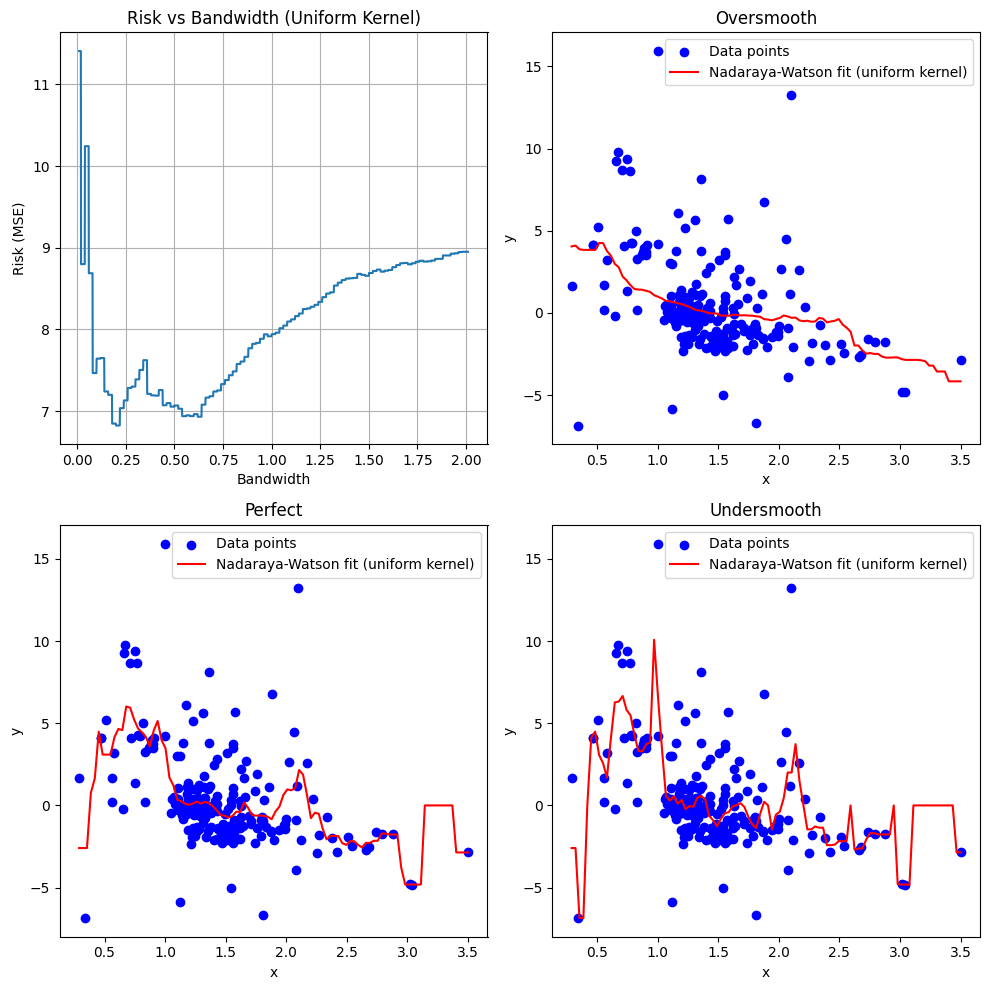

In [50]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_UniformKDE, risks_Ukde)
# axs[0, 0].set_xlim([0, 1])
# axs[0, 0].set_ylim([4, 10])
axs[0, 0].set_title('Risk vs Bandwidth (Uniform Kernel)')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)

# Oversmooth
kde = UniformKDE(bandwidth=best_bandwidth_Ukde * 5)
kde.fit(x_data, y_data)
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = kde.predict(x_fit)
axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (uniform kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
kde = UniformKDE(bandwidth=best_bandwidth_Ukde)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (uniform kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
kde = UniformKDE(bandwidth=best_bandwidth_Ukde / 2)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (uniform kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()

plt.tight_layout()
plt.savefig("uniform_kernel_regression.png")

plt.show()

In [51]:
class EpanechnikovKDE:
    def __init__(self, bandwidth=1.0):
        """Initialize the KDE model with the given bandwidth."""
        self.bandwidth = bandwidth
        self.x_data = None
        self.y_data = None

    def fit(self, x_data, y_data):
        """Fit the KDE model with the given x and y data."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)

    def __epanechnikov(self, x):
        return np.maximum(0, 0.75*(1-x**2))

    def epanechnikov_kernel(self, x, xi):
        """Epanechnikov kernel function."""
        return self.__epanechnikov((x-xi) / self.bandwidth)

    def predict(self, x):
        """Evaluate the Nadaraya-Watson estimator at points x."""
        func_val = []
        for point in x:
            weights = self.epanechnikov_kernel(point, self.x_data)
            numerator = np.sum(weights * self.y_data)
            denominator = np.sum(weights)
            
            if denominator > 0:
                func_val.append(numerator / denominator)
            else:
                func_val.append(0)  # Handle division by zero case
        return np.array(func_val)
    

In [52]:
bandwidths_EpanechnikovKDE = np.linspace(0.01, 2.01, 2000)
risks_Ekde = []
for bandwidth in bandwidths_EpanechnikovKDE:
    risk = k_fold_error(EpanechnikovKDE, x_data, y_data, bandwidth)
    # print(bandwidth, risk)
    risks_Ekde.append(risk)

best_bandwidth_Ekde = bandwidths_EpanechnikovKDE[np.argmin(risks_Ekde)]
print(f"bandwidth corresponding to minimum estimated risk is {best_bandwidth_Ekde}")

bandwidth corresponding to minimum estimated risk is 0.3201550775387694


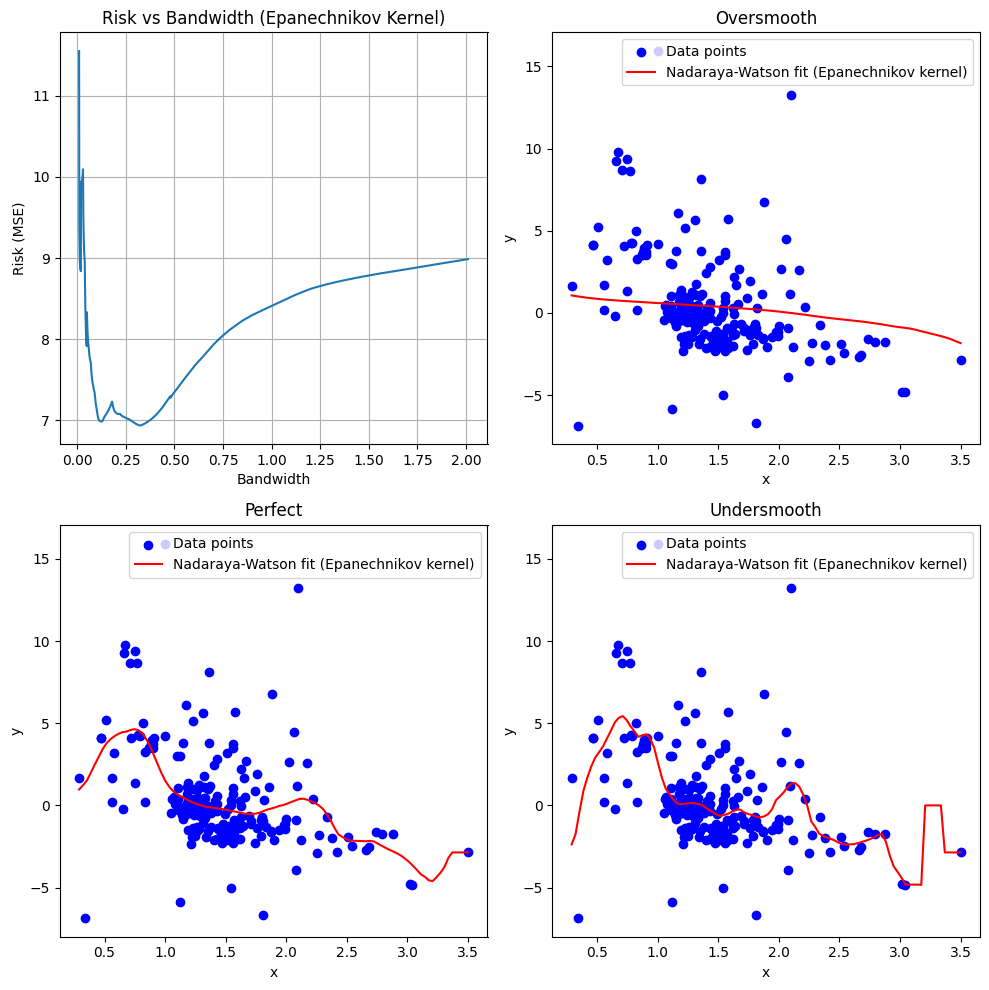

In [53]:
# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_EpanechnikovKDE, risks_Ekde)
axs[0, 0].set_title('Risk vs Bandwidth (Epanechnikov Kernel)')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)

# Oversmooth
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde * 5)
kde.fit(x_data, y_data)
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = kde.predict(x_fit)
axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde / 2)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()

plt.tight_layout()
plt.savefig("epanechnikov_kernel_regression.png")

plt.show()

### Comparing Plots of both Estimates

<!-- 1. Can you empirically corroborate above statement using plots ? Are all kernel functions similarly dependent on choice of optimal bandwidth ? -->

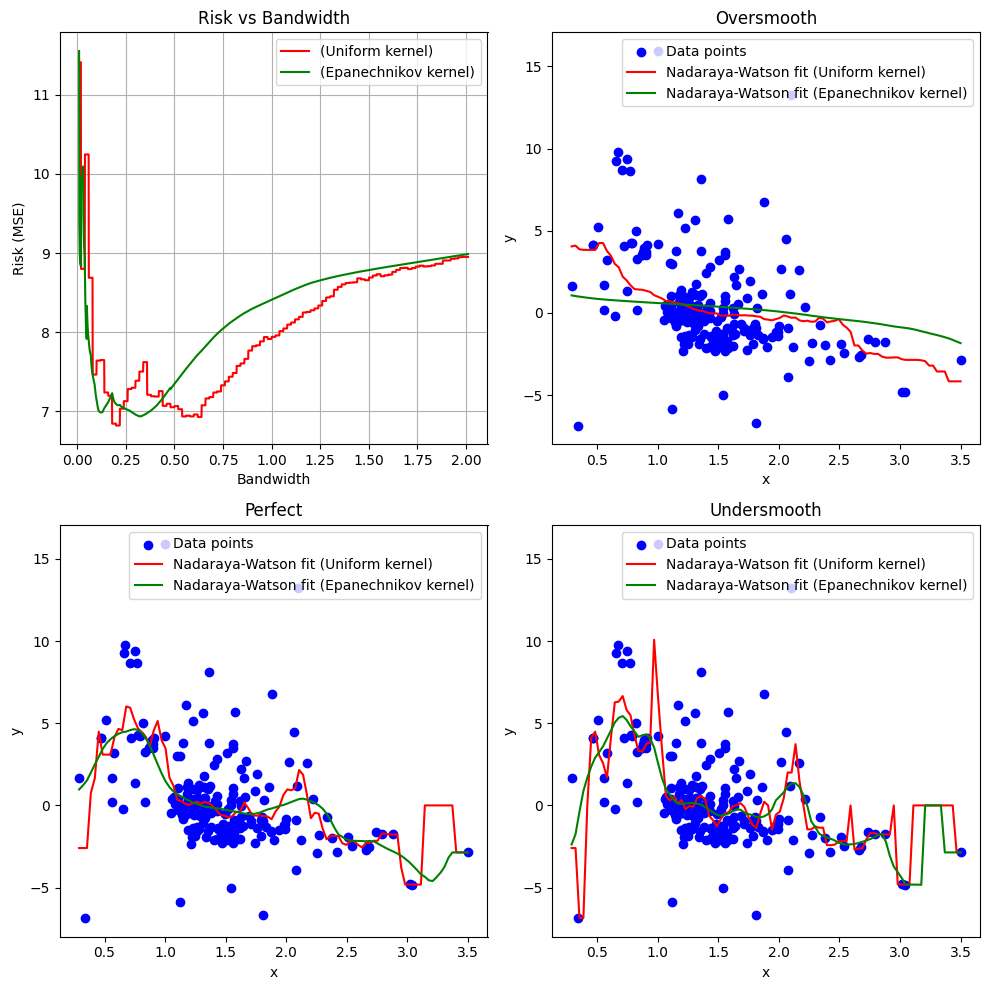

In [54]:
# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_UniformKDE, risks_Ukde, color='red', label='(Uniform kernel)')
axs[0, 0].plot(bandwidths_EpanechnikovKDE, risks_Ekde, color='green', label='(Epanechnikov kernel)')
axs[0, 0].set_title('Risk vs Bandwidth')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)
axs[0, 0].legend()

# Oversmooth
Ukde = UniformKDE(bandwidth=best_bandwidth_Ukde * 5)
Ukde.fit(x_data, y_data)
x_fitU = np.linspace(min(x_data), max(x_data), 100)
y_fitU = Ukde.predict(x_fit)

Ekde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde * 5)
Ekde.fit(x_data, y_data)
x_fitE = np.linspace(min(x_data), max(x_data), 100)
y_fitE = Ekde.predict(x_fit)

axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fitU, y_fitU, color='red', label='Nadaraya-Watson fit (Uniform kernel)')
axs[0, 1].plot(x_fitE, y_fitE, color='green', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
Ukde = UniformKDE(bandwidth=best_bandwidth_Ukde)
Ukde.fit(x_data, y_data)
x_fitU = np.linspace(min(x_data), max(x_data), 100)
y_fitU = Ukde.predict(x_fit)

Ekde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde)
Ekde.fit(x_data, y_data)
x_fitE = np.linspace(min(x_data), max(x_data), 100)
y_fitE = Ekde.predict(x_fit)

axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fitU, y_fitU, color='red', label='Nadaraya-Watson fit (Uniform kernel)')
axs[1, 0].plot(x_fitE, y_fitE, color='green', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
Ukde = UniformKDE(bandwidth=best_bandwidth_Ukde / 2)
Ukde.fit(x_data, y_data)
x_fitU = np.linspace(min(x_data), max(x_data), 100)
y_fitU = Ukde.predict(x_fit)

Ekde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde / 2)
Ekde.fit(x_data, y_data)
x_fitE = np.linspace(min(x_data), max(x_data), 100)
y_fitE = Ekde.predict(x_fit)

axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fitU, y_fitU, color='red', label='Nadaraya-Watson fit (Uniform kernel)')
axs[1, 1].plot(x_fitE, y_fitE, color='green', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

## Is optimal bandwidth dependent on choice of kernel ?

In [55]:
best_bandwidth_Ekde, best_bandwidth_Ukde

(0.3201550775387694, 0.20009504752376187)

Well, as we can see optimal bandwidth is highly dependent on the kernel being used.

## K-fold Cross-validation


In [56]:
# Re-shuffling of data
data = data.iloc[np.random.permutation(len(data))].reset_index(drop=True)

x_data_test = data['RI'].values
y_data_test = data['Al'].values

In [57]:
UniformKDE_k_fold_error = k_fold_error(UniformKDE, x_data_test, y_data_test ,best_bandwidth_Ukde)
EpanechnikovKDE_k_fold_error = k_fold_error(EpanechnikovKDE, x_data_test, y_data_test, best_bandwidth_Ekde)

UniformKDE_k_fold_error, EpanechnikovKDE_k_fold_error

(0.3998045890478964, 0.24823054985397283)

## Which is better by what margin ?

In [58]:
diff=2*(EpanechnikovKDE_k_fold_error - UniformKDE_k_fold_error)/(UniformKDE_k_fold_error + EpanechnikovKDE_k_fold_error)

if diff > 0:
    print(f"Uniform KDE has {diff*100:.2f}% less error than Epanechnikov KDE.")
else:
    print(f"Epanechnikov KDE has {(-diff*100):.2f}% less error than Uniform KDE.")

Epanechnikov KDE has 46.78% less error than Uniform KDE.
